# Notebook – Faysal
## Project: Voorspelling Jeugdpopulatie Almere (CBS Wijken & Buurten)

**Doel van dit notebook (fase 1):**  
De gemeente Almere wil beter kunnen inspelen op de zorgbehoeften van kinderen en jongeren in verschillende wijken. Wijken met een relatief groot aantal jongeren kunnen bijvoorbeeld meer ondersteuning nodig hebben van wijkteams of jeugdzorgvoorzieningen.

Om deze reden wil de gemeente inzicht krijgen in hoe de jeugdpopulatie zich ontwikkelt per wijk. Door deze ontwikkeling beter te begrijpen en te voorspellen, kan de gemeente beleid en ondersteuning tijdig aanpassen. 

Windesheim Data Science opdrach…

De analyse wordt uitgevoerd op basis van open data van het CBS (Kerncijfers wijken en buurten). Deze dataset bevat demografische gegevens per wijk, zoals het totaal aantal inwoners en het aantal inwoners per leeftijdsgroep.

**Business probleem**

De gemeente beschikt over historische data over de bevolkingssamenstelling per wijk, maar heeft nog geen eenvoudig model dat kan helpen bij het inschatten van toekomstige ontwikkelingen in de jeugdpopulatie.

Zonder dit inzicht is het moeilijker om:

- capaciteit van wijkteams te plannen
- jeugdzorgvoorzieningen goed te verdelen
- tijdig te reageren op groei van het aantal jongeren in bepaalde wijken

**Business vraag**

Hoe ontwikkelt het aantal jongeren in de leeftijdsgroepen 0–15 jaar en 15–25 jaar zich per wijk in Almere, en kan deze ontwikkeling worden gebruikt om toekomstige aantallen te voorspellen?

**Data mining doel**

Het doel van dit notebook is om een eenvoudig voorspellend model te bouwen dat de relatie onderzoekt tussen verschillende leeftijdsgroepen binnen een wijk.

Specifiek wordt onderzocht of het aantal jongeren van 15–25 jaar samenhangt met het aantal kinderen van 0–15 jaar in dezelfde wijk.

Dit gebeurt met een enkelvoudig lineair regressiemodel.

**Modelopzet**

Voor dit individuele model wordt gebruik gemaakt van:

Predictor
Aantal jongeren 15–25 jaar

Target
Aantal jongeren 0–15 jaar

De analyse wordt uitgevoerd per wijk, zodat verschillen tussen wijken zichtbaar blijven.

**Onderzoeksvraag van dit model**

Bestaat er een structurele relatie tussen het aantal jongeren van 15–25 jaar en het aantal kinderen van 0–15 jaar binnen wijken in Almere?

Met andere woorden:

Hebben wijken met relatief veel jongeren ook relatief veel kinderen?

**Dataset**

Voor dit model wordt gebruik gemaakt van de dataset:

../../data/processed/df_v10_ratio_temp.csv

Deze dataset bevat demografische gegevens per wijk en jaar, waaronder:
- Wijk
- Jaar
- Totaal aantal inwoners
- Aantal jongeren 0–15 jaar
- Aantal jongeren 15–25 jaar

Deze gegevens vormen de basis voor het regressiemodel dat in latere fases wordt gebouwd.

In [1]:
import pandas as pd
from pathlib import Path
 
path = Path("../../data/processed/df_v6_clean_final.csv")
 
df = pd.read_csv(path)
df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar
0,2018-01-01,WK003401,22790,3975,2420,2018
1,2019-01-01,WK003401,22875,3945,2415,2019
2,2020-01-01,WK003401,23275,4005,2485,2020
3,2021-01-01,WK003401,23530,4180,2465,2021
4,2022-01-01,WK003401,1635,175,150,2022


In [2]:
df.shape, df.columns

((237, 6),
 Index(['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8',
        'k_15Tot25Jaar_9', 'Jaar'],
       dtype='str'))

In [3]:
df.info()
df.describe(include="all")
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Peildatum         237 non-null    str  
 1   Wijk              237 non-null    str  
 2   AantalInwoners_5  237 non-null    int64
 3   k_0Tot15Jaar_8    237 non-null    int64
 4   k_15Tot25Jaar_9   237 non-null    int64
 5   Jaar              237 non-null    int64
dtypes: int64(4), str(2)
memory usage: 11.2 KB


np.int64(0)

In [4]:
df["Peildatum"] = pd.to_datetime(df["Peildatum"], errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year
 
df[["Peildatum", "Jaar"]].head()

,Peildatum,Jaar
0,2018-01-01,2018
1,2019-01-01,2019
2,2020-01-01,2020
3,2021-01-01,2021
4,2022-01-01,2022


In [5]:
kol_totaal = "AantalInwoners_5"
kol_0_15 = "k_0Tot15Jaar_8"
kol_15_25 = "k_15Tot25Jaar_9"
 
checks = {
    "negatief_0_15": (df[kol_0_15] < 0).sum(),
    "negatief_15_25": (df[kol_15_25] < 0).sum(),
    "negatief_totaal": (df[kol_totaal] < 0).sum(),
    "0_15_groter_dan_totaal": (df[kol_0_15] > df[kol_totaal]).sum(),
    "15_25_groter_dan_totaal": (df[kol_15_25] > df[kol_totaal]).sum(),
}
 
checks
df.groupby("Jaar")["Wijk"].nunique().sort_index()

Jaar
2018     5
2019     5
2020     5
2021     5
2022    53
2023    54
2024    55
2025    55
Name: Wijk, dtype: int64

In [6]:
df["pct_0_15"] = (df[kol_0_15] / df[kol_totaal]) * 100
df["pct_15_25"] = (df[kol_15_25] / df[kol_totaal]) * 100
 
df[["Wijk", "Jaar", kol_totaal, kol_0_15, kol_15_25, "pct_0_15", "pct_15_25"]].head()
 
df[["pct_0_15", "pct_15_25"]].describe()
 
output_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df.to_csv(output_path, index=False)
 
output_path.as_posix()

'../../data/processed/df_v8_ready_for_analysis.csv'

---
# Fase 2 – Data Understanding


**Doel:** In deze fase wordt de dataset verkend om inzicht te krijgen in de structuur van de data en mogelijke relaties tussen variabelen.

Het doel is om te begrijpen:

- welke variabelen beschikbaar zijn
- hoe de data is opgebouwd
- of er patronen zichtbaar zijn tussen bevolkingsgrootte en jeugdgroepen
- of er verschillen bestaan tussen wijken

Dit helpt om te bepalen welke variabelen geschikt zijn voor het regressiemodel in fase 4.

In [7]:
import pandas as pd

df = pd.read_csv("../../data/processed/df_v10_ratio_temp.csv")

df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


De eerste rijen van de dataset worden bekeken om een eerste indruk te krijgen van de structuur van de data. Hier is zichtbaar welke kolommen aanwezig zijn en hoe de waarden eruit zien.

In [8]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Peildatum         20 non-null     str    
 1   Wijk              20 non-null     str    
 2   AantalInwoners_5  20 non-null     int64  
 3   k_0Tot15Jaar_8    20 non-null     int64  
 4   k_15Tot25Jaar_9   20 non-null     int64  
 5   Jaar              20 non-null     int64  
 6   pct_0_15          20 non-null     float64
 7   pct_15_25         20 non-null     float64
 8   Ratio_0_15        20 non-null     float64
 9   Ratio_15_25       20 non-null     float64
dtypes: float64(4), int64(4), str(2)
memory usage: 1.7 KB


Met deze stappen wordt de structuur van de dataset onderzocht:

- df.shape laat zien hoeveel rijen en kolommen de dataset bevat
- df.columns toont de beschikbare variabelen
- df.info() geeft inzicht in datatypes en ontbrekende waarden

Dit helpt om te controleren of de dataset geschikt is voor verdere analyse.

In [9]:
df.describe()

,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,41922.500000,7855.500000,5387.000000,2019.500000,20.157998,11.101826,0.201580,0.111018
std,38928.477551,6790.991692,5524.028469,1.147079,3.198692,2.285306,0.031987,0.022853
min,2655.000000,465.000000,235.000000,2018.000000,17.207304,8.333333,0.172073,0.083333
25%,14881.250000,3768.750000,1347.500000,2018.750000,17.543915,8.848973,0.175439,0.088490
50%,23075.000000,4232.500000,2442.500000,2019.500000,18.586310,10.588035,0.185863,0.105880
75%,56973.750000,11013.750000,7910.000000,2020.250000,23.012959,13.660952,0.230130,0.136610
max,109805.000000,19915.000000,14975.000000,2021.000000,25.566826,13.963490,0.255668,0.139635


Met beschrijvende statistiek wordt gekeken naar:

- gemiddelde waarden
- minimum en maximum
- spreiding van populatievariabelen

Dit helpt om te controleren of waarden realistisch zijn en of er mogelijke uitschieters aanwezig zijn.

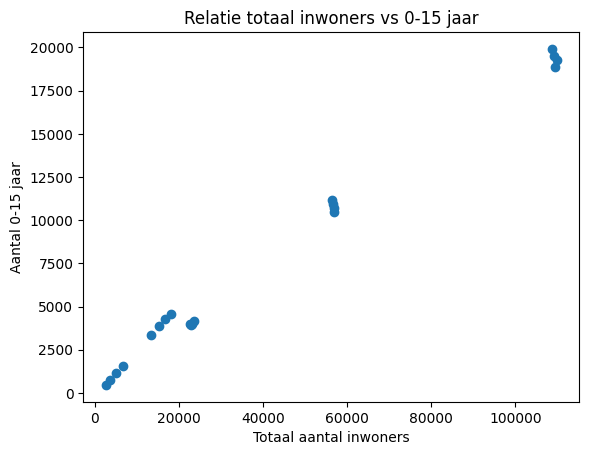

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["AantalInwoners_5"], df["k_0Tot15Jaar_8"])
plt.xlabel("Totaal aantal inwoners")
plt.ylabel("Aantal 0-15 jaar")
plt.title("Relatie totaal inwoners vs 0-15 jaar")
plt.show()

Deze grafiek toont de relatie tussen het totaal aantal inwoners en het aantal kinderen van 0–15 jaar per wijk.

De punten liggen duidelijk op een stijgende lijn. Dit betekent dat wijken met meer inwoners meestal ook meer kinderen hebben.

Dit is logisch, omdat grotere wijken automatisch meer inwoners in alle leeftijdsgroepen hebben.

In [11]:
df[[
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9"
]].corr()

,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9
AantalInwoners_5,1.000000,0.996688,0.998529
k_0Tot15Jaar_8,0.996688,1.000000,0.995371
k_15Tot25Jaar_9,0.998529,0.995371,1.000000


De correlatiematrix laat zien dat er een zeer sterke positieve samenhang bestaat tussen:

totaal aantal inwoners

aantal kinderen (0–15)

aantal jongeren (15–25)

De correlatie ligt rond 0.99, wat betekent dat deze variabelen bijna volledig samen bewegen.

Dit komt waarschijnlijk doordat grotere wijken meer inwoners hebben in alle leeftijdsgroepen.

In [12]:
df.groupby("Wijk")[[
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9"
]].mean().sort_values(by="k_0Tot15Jaar_8", ascending=False)

,k_0Tot15Jaar_8,k_15Tot25Jaar_9
Wijk,,
WK003402,19396.25,14845.00
WK003403,10831.25,7840.00
WK003404,4036.25,1418.75
WK003401,4026.25,2446.25
WK003405,987.50,385.00


Hier wordt gekeken of bepaalde wijken structureel meer jongeren hebben dan andere.

Dit helpt om te begrijpen of de jeugdpopulatie gelijkmatig verdeeld is over Almere of dat sommige wijken duidelijk grotere jeugdgroepen hebben.

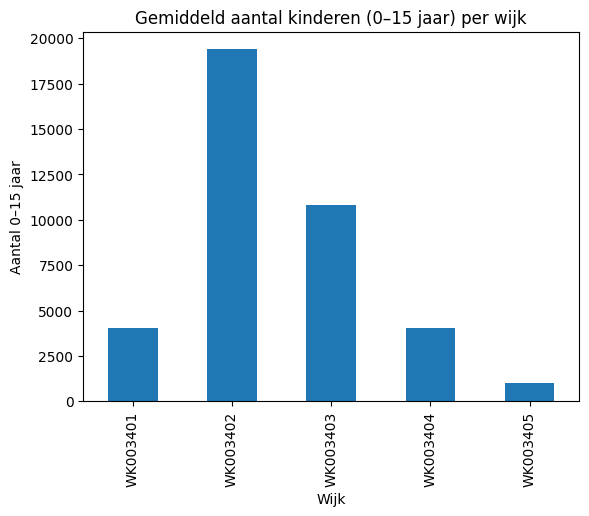

In [13]:
df.groupby("Wijk")["k_0Tot15Jaar_8"].mean().plot(
    kind="bar",
    title="Gemiddeld aantal kinderen (0–15 jaar) per wijk"
)
plt.ylabel("Aantal 0–15 jaar")
plt.xlabel("Wijk")
plt.show()
 

Deze grafiek toont het gemiddelde aantal kinderen van 0–15 jaar per wijk.

Uit de grafiek blijkt dat sommige wijken duidelijk grotere jeugdpopulaties hebben dan andere. Dit betekent dat de verdeling van kinderen over Almere niet gelijkmatig is. Sommige wijken hebben structureel meer kinderen en kunnen daardoor een grotere vraag naar jeugdzorg of onderwijsvoorzieningen hebben.

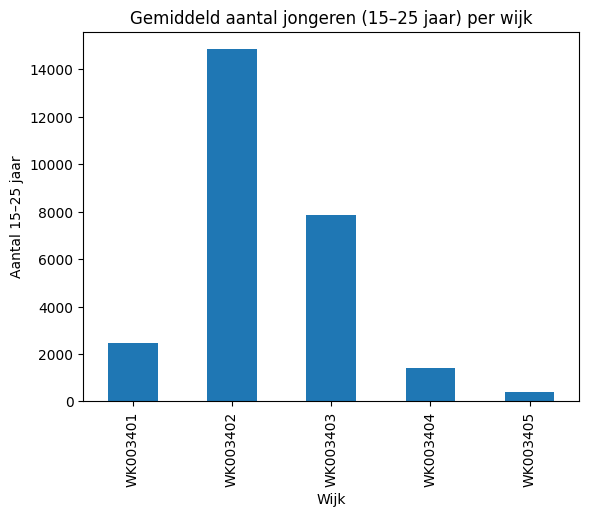

In [14]:
df.groupby("Wijk")["k_15Tot25Jaar_9"].mean().plot(
    kind="bar",
    title="Gemiddeld aantal jongeren (15–25 jaar) per wijk"
)

plt.ylabel("Aantal 15–25 jaar")
plt.xlabel("Wijk")
plt.show()

Deze grafiek toont het gemiddelde aantal jongeren van 15–25 jaar per wijk.

Net als bij de groep 0–15 jaar zijn er duidelijke verschillen tussen wijken. Sommige wijken hebben aanzienlijk meer jongeren dan andere. Dit laat zien dat de leeftijdsstructuur tussen wijken verschilt.

Deze verschillen zijn belangrijk voor het model, omdat voorspellingen per wijk kunnen variëren.

In [15]:
print("Aantal rijen:", len(df))
print("Unieke Wijk-waarden:", df["Wijk"].nunique())
print("Voorbeeld Wijk-waarden:", df["Wijk"].dropna().unique()[:10])

if "Gemeentenaam" in df.columns:
    print("\nGemeentenaam top:", df["Gemeentenaam"].value_counts().head())

if "SoortRegio" in df.columns:
    print("\nSoortRegio verdeling:", df["SoortRegio"].value_counts().head())

Aantal rijen: 20
Unieke Wijk-waarden: 5
Voorbeeld Wijk-waarden: <StringArray>
['WK003401', 'WK003402', 'WK003403', 'WK003404', 'WK003405']
Length: 5, dtype: str


---
# Fase 3 – Data Preparation


**Doel:** In deze fase wordt de dataset voorbereid voor modellering.
De verschillende feature-datasets van het team worden samengevoegd tot één modelklare dataset.

De merge gebeurt op de sleutel:

Wijk

Jaar

De uiteindelijke output van deze fase is:

../../data/processed/df_v12_model_ready.csv

Deze dataset zal in fase 4 gebruikt worden voor het regressiemodel.

In [16]:
import pandas as pd
from pathlib import Path

base_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df_base = pd.read_csv(base_path)

df_base.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312


De basisdataset bevat demografische gegevens per wijk en per jaar.
In de eerste rijen is te zien dat elke observatie bestaat uit een combinatie van Peildatum, Wijk en Jaar.

Voor wijk WK003401 zijn bijvoorbeeld meerdere jaren aanwezig (2018 t/m 2022).
Dit bevestigt dat de dataset een tijdreeks per wijk bevat.

In [17]:
df_base[["Wijk","Jaar"]].head()

df_base.duplicated(subset=["Wijk","Jaar"]).sum()

np.int64(0)

De controle laat zien dat er 0 duplicaten aanwezig zijn voor de combinatie Wijk + Jaar.

Dit betekent dat iedere combinatie van wijk en jaar slechts één keer voorkomt in de dataset.
Hierdoor kan de dataset veilig gebruikt worden voor het samenvoegen met andere datasets.

In [18]:
ratio_path = Path("../../data/processed/df_v10_ratio_temp.csv")

df_ratio = pd.read_csv(ratio_path)

df_ratio.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


De ratio-dataset bevat aanvullende variabelen die de verhouding weergeven tussen de leeftijdsgroepen en de totale bevolking.

Bijvoorbeeld:

Voor wijk WK003401 in 2018:

Ratio_0_15 = 0.174419
Ratio_15_25 = 0.106187

Dit betekent dat:

- ongeveer 17,4% van de bevolking 0–15 jaar is
- ongeveer 10,6% van de bevolking 15–25 jaar is

Deze ratio’s maken het mogelijk om wijken beter met elkaar te vergelijken, omdat ze rekening houden met verschillen in bevolkingsgrootte.

In [19]:
df_ratio = df_ratio[[
    "Wijk",
    "Jaar",
    "Ratio_0_15",
    "Ratio_15_25"
]]

df_ratio.head()

,Wijk,Jaar,Ratio_0_15,Ratio_15_25
0,WK003401,2018,0.174419,0.106187
1,WK003401,2019,0.172459,0.105574
2,WK003401,2020,0.172073,0.106767
3,WK003401,2021,0.177646,0.104760
4,WK003402,2018,0.183042,0.136857


Niet alle kolommen uit de ratio-dataset zijn nodig voor het model.

Daarom worden alleen de variabelen geselecteerd die als feature gebruikt kunnen worden in het regressiemodel.

Dit voorkomt dat onnodige kolommen worden meegenomen in de uiteindelijke dataset.

In [20]:
df_base["Wijk"] = df_base["Wijk"].astype(str).str.strip()
df_ratio["Wijk"] = df_ratio["Wijk"].astype(str).str.strip()

df_base["Jaar"] = df_base["Jaar"].astype(int)
df_ratio["Jaar"] = df_ratio["Jaar"].astype(int)

In [21]:
df_merged = df_base.merge(
    df_ratio,
    on=["Wijk","Jaar"],
    how="left"
)

df_merged.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312,NaN,NaN


Na het uitvoeren van de merge zijn de kolommen Ratio_0_15 en Ratio_15_25 gevuld met NaN-waarden.

Dit betekent dat er geen overeenkomstige rijen zijn gevonden tussen de basisdataset en de ratio-dataset op basis van de sleutel Wijk + Jaar.

Hoewel het aantal rijen gelijk blijft (237), worden de ratio-waarden niet correct gekoppeld.

Dit wijst erop dat er een verschil bestaat in de sleutelkolommen tussen beide datasets, bijvoorbeeld in datatype of tekstformaat.

In [22]:
print("Rows base:", len(df_base))
print("Rows merged:", len(df_merged))

df_merged.isnull().sum()

Rows base: 237
Rows merged: 237


Peildatum             0
Wijk                  0
AantalInwoners_5      0
k_0Tot15Jaar_8        0
k_15Tot25Jaar_9       0
Jaar                  0
pct_0_15              0
pct_15_25             0
Ratio_0_15          217
Ratio_15_25         217
dtype: int64

Na de merge worden twee controles uitgevoerd:

Aantal rijen controleren

Het aantal rijen moet gelijk blijven.
Als het aantal rijen verandert, betekent dit meestal dat de merge verkeerd is uitgevoerd.

Ontbrekende waarden controleren

Hier wordt gekeken of er NaN-waarden zijn ontstaan bij het toevoegen van de nieuwe features.

In [23]:
df_base.dtypes
df_ratio.dtypes

Wijk               str
Jaar             int64
Ratio_0_15     float64
Ratio_15_25    float64
dtype: object

Alleen variabelen die relevant zijn voor het model worden geselecteerd.

In [24]:
# 1) Filter ratio naar dezelfde jaren als de basis (2018-2021)
df_ratio = df_ratio[df_ratio["Jaar"].isin(df_base["Jaar"].unique())].copy()

print("Jaren base:", sorted(df_base["Jaar"].unique()))
print("Jaren ratio (na filter):", sorted(df_ratio["Jaar"].unique()))

Jaren base: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Jaren ratio (na filter): [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


In [25]:
model_cols = [
    "Wijk",
    "Jaar",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
    "Ratio_0_15",
    "Ratio_15_25"
]

df_model = df_merged[model_cols].copy()

df_model.head()

,Wijk,Jaar,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Ratio_0_15,Ratio_15_25
0,WK003401,2018,22790,3975,2420,0.174419,0.106187
1,WK003401,2019,22875,3945,2415,0.172459,0.105574
2,WK003401,2020,23275,4005,2485,0.172073,0.106767
3,WK003401,2021,23530,4180,2465,0.177646,0.104760
4,WK003401,2022,1635,175,150,NaN,NaN


Niet alle kolommen uit de dataset zijn relevant voor het model.

Daarom wordt een subset van variabelen geselecteerd die gebruikt worden in fase 4.

Deze variabelen bevatten zowel:

- absolute aantallen
- relatieve demografische verhoudingen

In [26]:
# 2) Hoeveel matches hebben we echt?
matches = df_merged[["Ratio_0_15", "Ratio_15_25"]].notna().all(axis=1).sum()
totaal = len(df_merged)

print("Aantal rijen met ratio's gevuld:", matches, "van", totaal)
print("Aantal rijen zonder ratio's:", totaal - matches)

Aantal rijen met ratio's gevuld: 20 van 237
Aantal rijen zonder ratio's: 217


Na de merge controleer ik hoeveel wijk-jaar rijen daadwerkelijk ratio’s hebben gekregen. In mijn output zie ik dat slechts een klein deel gevuld is (bijv. 20 van 237). Dit betekent dat het ratio-bestand niet alle wijken bevat.

In [27]:
df_model.dtypes

Wijk                    str
Jaar                  int64
AantalInwoners_5      int64
k_0Tot15Jaar_8        int64
k_15Tot25Jaar_9       int64
Ratio_0_15          float64
Ratio_15_25         float64
dtype: object

Machine-learning modellen werken alleen met numerieke variabelen.

Daarom controleren we of alle modelvariabelen het juiste datatype hebben.

De kolom Wijk blijft een string omdat deze alleen als identificatie dient.

In [28]:
output_path = Path("../../data/processed/df_v12_model_ready.csv")

df_model.to_csv(output_path, index=False)

output_path

WindowsPath('../../data/processed/df_v12_model_ready.csv')

De uiteindelijke modeldataset wordt opgeslagen in de map data/processed.

Deze dataset vormt de definitieve input voor fase 4 (Modeling), waarin het regressiemodel wordt gebouwd.

In [29]:
df_model.groupby("Wijk")["Jaar"].min(), df_model.groupby("Wijk")["Jaar"].max()

(Wijk
 WK003401    2018
 WK003402    2018
 WK003403    2018
 WK003404    2018
 WK003405    2018
 WK003406    2022
 WK003407    2022
 WK003408    2022
 WK003409    2022
 WK003410    2022
 WK003411    2022
 WK003414    2022
 WK003417    2022
 WK003418    2022
 WK003419    2022
 WK003420    2022
 WK003421    2022
 WK003422    2022
 WK003423    2022
 WK003424    2022
 WK003425    2022
 WK003426    2022
 WK003427    2022
 WK003428    2022
 WK003429    2022
 WK003430    2022
 WK003431    2022
 WK003432    2024
 WK003435    2023
 WK003437    2022
 WK003441    2022
 WK003442    2022
 WK003443    2022
 WK003444    2022
 WK003445    2022
 WK003446    2022
 WK003447    2022
 WK003448    2022
 WK003449    2022
 WK003450    2022
 WK003451    2022
 WK003452    2022
 WK003453    2022
 WK003456    2022
 WK003458    2022
 WK003459    2025
 WK003460    2022
 WK003461    2022
 WK003462    2022
 WK003463    2022
 WK003465    2022
 WK003466    2022
 WK003475    2022
 WK003476    2022
 WK003477    2022
 WK0

In [30]:
df_ratio["Jaar"].unique()


array([2018, 2019, 2020, 2021])

In [31]:
df_base["Jaar"].unique()


array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

---
# Fase 4 – Modeling 

**Doel:** In deze fase wordt een eenvoudig lineair regressiemodel gebruikt om de ontwikkeling van de jeugdpopulatie per wijk te verkennen op basis van de historische jaren 2018 t/m 2021.

Er is bewust gekozen om alleen deze jaren te gebruiken, omdat in latere jaren een duidelijke breuk zichtbaar is in sommige wijken. Daardoor zijn de waarden vanaf 2022 niet goed vergelijkbaar met de eerdere jaren.

Het model wordt daarom gebruikt als een eenvoudige trendinschatting, niet als een volledig betrouwbare langetermijnvoorspelling.

De voorspelling wordt uitgevoerd per wijk voor de leeftijdsgroepen:

k_0Tot15Jaar_8

k_15Tot25Jaar_9

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("../../data/processed/df_v12_model_ready.csv")

df.head()

,Wijk,Jaar,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Ratio_0_15,Ratio_15_25
0,WK003401,2018,22790,3975,2420,0.174419,0.106187
1,WK003401,2019,22875,3945,2415,0.172459,0.105574
2,WK003401,2020,23275,4005,2485,0.172073,0.106767
3,WK003401,2021,23530,4180,2465,0.177646,0.104760
4,WK003401,2022,1635,175,150,NaN,NaN


De modeldataset bevat de variabelen die in fase 3 zijn voorbereid voor modellering.
Elke rij stelt een combinatie van wijk en jaar voor.

Voor deze fase gebruiken we vooral:

- Wijk
- Jaar
- k_0Tot15Jaar_8
- k_15Tot25Jaar_9

In [55]:
df_model = df[df["Jaar"].isin([2018, 2019, 2020, 2021])].copy()

print("Gebruikte jaren:", sorted(df_model["Jaar"].unique()))
print("Aantal wijken:", df_model["Wijk"].nunique())
df_model.head()

Gebruikte jaren: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Aantal wijken: 5


,Wijk,Jaar,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Ratio_0_15,Ratio_15_25
0,WK003401,2018,22790,3975,2420,0.174419,0.106187
1,WK003401,2019,22875,3945,2415,0.172459,0.105574
2,WK003401,2020,23275,4005,2485,0.172073,0.106767
3,WK003401,2021,23530,4180,2465,0.177646,0.104760
8,WK003402,2018,108800,19915,14890,0.183042,0.136857


Hier worden alleen de jaren 2018 t/m 2021 geselecteerd.

De reden hiervoor is dat in de dataset vanaf 2022 duidelijke sprongen zichtbaar zijn die waarschijnlijk samenhangen met veranderingen in de wijkindeling. Om het model niet te laten trainen op onvergelijkbare data, worden alleen de consistente jaren gebruikt.

In [57]:
toekomstige_jaren = pd.DataFrame({"Jaar": list(range(2026, 2036))})
toekomstige_jaren

,Jaar
0,2026
1,2027
2,2028
3,2029
4,2030
5,2031
6,2032
7,2033
8,2034
9,2035


Hier worden de jaren 2026 t/m 2035 aangemaakt.
Dit zijn de jaren waarvoor het model trendmatige voorspellingen maakt.

In [58]:
voorspellingen_0_15 = []

for wijk in df_model["Wijk"].unique():
    subset = df_model[df_model["Wijk"] == wijk].copy()

    # Alleen wijken met minimaal 2 meetpunten gebruiken
    if subset["Jaar"].nunique() < 2:
        continue

    X = subset[["Jaar"]]
    y = subset["k_0Tot15Jaar_8"]

    model = LinearRegression()
    model.fit(X, y)

    y_future = model.predict(toekomstige_jaren)

    # Negatieve voorspellingen afkappen op 0
    y_future = np.maximum(y_future, 0)

    df_future = toekomstige_jaren.copy()
    df_future["Wijk"] = wijk
    df_future["voorspelling_0_15"] = y_future

    voorspellingen_0_15.append(df_future)

df_voorspelling_0_15 = pd.concat(voorspellingen_0_15, ignore_index=True)

df_voorspelling_0_15.head()

,Jaar,Wijk,voorspelling_0_15
0,2026,WK003401,4465.0
1,2027,WK003401,4532.5
2,2028,WK003401,4600.0
3,2029,WK003401,4667.5
4,2030,WK003401,4735.0


Voor iedere wijk wordt apart een lineair regressiemodel getraind met:

- Jaar als predictor
- k_0Tot15Jaar_8 als target

Daarna wordt voor elk jaar van 2026 t/m 2035 een voorspelling gemaakt.

Negatieve uitkomsten worden op 0 gezet, omdat negatieve aantallen jongeren inhoudelijk onmogelijk zijn.

In [60]:
voorspellingen_15_25 = []

for wijk in df_model["Wijk"].unique():
    subset = df_model[df_model["Wijk"] == wijk].copy()

    if subset["Jaar"].nunique() < 2:
        continue

    X = subset[["Jaar"]]
    y = subset["k_15Tot25Jaar_9"]

    model = LinearRegression()
    model.fit(X, y)

    y_future = model.predict(toekomstige_jaren)

    # Negatieve voorspellingen afkappen op 0
    y_future = np.maximum(y_future, 0)

    df_future = toekomstige_jaren.copy()
    df_future["Wijk"] = wijk
    df_future["voorspelling_15_25"] = y_future

    voorspellingen_15_25.append(df_future)

df_voorspelling_15_25 = pd.concat(voorspellingen_15_25, ignore_index=True)

df_voorspelling_15_25.head()

,Jaar,Wijk,voorspelling_15_25
0,2026,WK003401,2579.5
1,2027,WK003401,2600.0
2,2028,WK003401,2620.5
3,2029,WK003401,2641.0
4,2030,WK003401,2661.5


Deze stap doet hetzelfde als de vorige, maar dan voor de leeftijdsgroep 15–25 jaar.

Ook hier worden negatieve voorspellingen op 0 gezet, omdat zulke waarden inhoudelijk niet mogelijk zijn.

In [61]:
df_voorspelling = df_voorspelling_0_15.merge(
    df_voorspelling_15_25,
    on=["Wijk", "Jaar"],
    how="inner"
)

df_voorspelling.head()

,Jaar,Wijk,voorspelling_0_15,voorspelling_15_25
0,2026,WK003401,4465.0,2579.5
1,2027,WK003401,4532.5,2600.0
2,2028,WK003401,4600.0,2620.5
3,2029,WK003401,4667.5,2641.0
4,2030,WK003401,4735.0,2661.5


In deze stap worden de voorspellingen voor beide leeftijdsgroepen samengevoegd tot één overzichtelijke dataset.

De output bevat nu per wijk en per jaar:

- voorspelling voor 0–15 jaar
- voorspelling voor 15–25 jaar

In [63]:
output_path = "../../data/processed/df_voorspelling_2026_2035.csv"
df_voorspelling.to_csv(output_path, index=False)

output_path

'../../data/processed/df_voorspelling_2026_2035.csv'

De voorspelde waarden worden opgeslagen in een apart CSV-bestand.

Dit bestand kan later gebruikt worden voor visualisaties, vergelijking tussen wijken en rapportage.

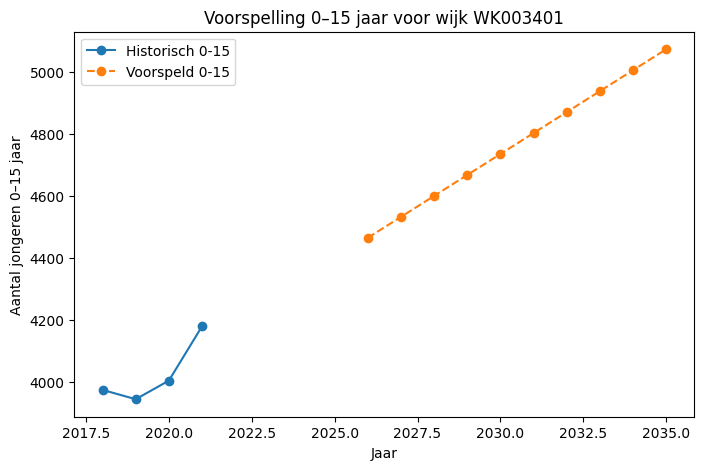

In [64]:
wijk_keuze = "WK003401"

historisch = df_model[df_model["Wijk"] == wijk_keuze]
toekomst = df_voorspelling[df_voorspelling["Wijk"] == wijk_keuze]

plt.figure(figsize=(8,5))

plt.plot(historisch["Jaar"], historisch["k_0Tot15Jaar_8"], marker="o", label="Historisch 0-15")
plt.plot(toekomst["Jaar"], toekomst["voorspelling_0_15"], marker="o", linestyle="--", label="Voorspeld 0-15")

plt.xlabel("Jaar")
plt.ylabel("Aantal jongeren 0–15 jaar")
plt.title(f"Voorspelling 0–15 jaar voor wijk {wijk_keuze}")
plt.legend()
plt.show()

Deze grafiek laat voor één wijk het verschil zien tussen:

- historische waarden uit 2018 t/m 2021
- voorspelde waarden voor 2026 t/m 2035

Doordat alleen de consistente jaren zijn gebruikt, wordt de trend niet meer verstoord door de breuk vanaf 2022.

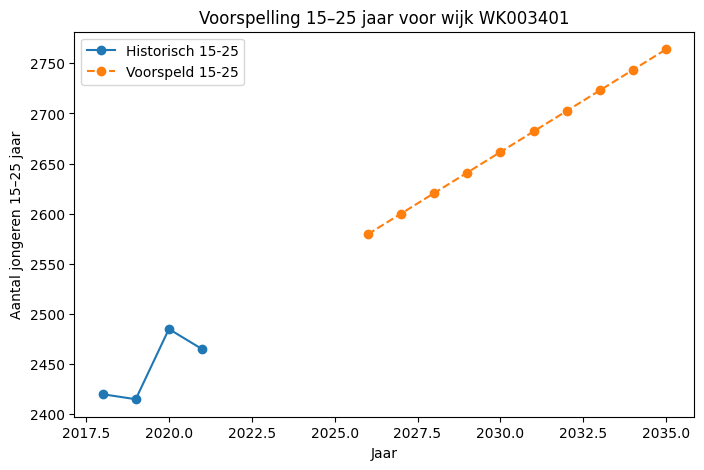

In [65]:
plt.figure(figsize=(8,5))

plt.plot(historisch["Jaar"], historisch["k_15Tot25Jaar_9"], marker="o", label="Historisch 15-25")
plt.plot(toekomst["Jaar"], toekomst["voorspelling_15_25"], marker="o", linestyle="--", label="Voorspeld 15-25")

plt.xlabel("Jaar")
plt.ylabel("Aantal jongeren 15–25 jaar")
plt.title(f"Voorspelling 15–25 jaar voor wijk {wijk_keuze}")
plt.legend()
plt.show()

Deze grafiek toont hetzelfde principe, maar dan voor de leeftijdsgroep 15–25 jaar.

Ook hier geldt dat de voorspelling alleen gebaseerd is op de jaren die onderling vergelijkbaar zijn.

**Het model maakt trendmatige voorspellingen per wijk op basis van de jaren 2018 t/m 2021. Er is bewust gekozen om de jaren vanaf 2022 niet in het model op te nemen, omdat in de data een duidelijke breuk zichtbaar is. Hierdoor zouden voorspellingen anders kunstmatig sterk dalen en inhoudelijk onbetrouwbaar worden.**

**De uitkomsten van dit model moeten daarom worden gezien als een eenvoudige trendverkenning. Het model houdt alleen rekening met tijd en niet met andere factoren zoals nieuwbouw, migratie of veranderingen in wijkgrenzen. Daardoor zijn de voorspellingen bruikbaar als eerste indicatie, maar niet als harde beleidsvoorspelling.**

---
# Fase 5 – Evaluatie & Reflectie 

## Onderbouwing:


In deze analyse is een eenvoudig lineair regressiemodel gebruikt om de ontwikkeling van de jeugdpopulatie per wijk te verkennen. Het model maakt gebruik van het jaar als predictor en voorspelt het aantal jongeren in de leeftijdsgroepen 0–15 jaar en 15–25 jaar. De training van het model is uitgevoerd op de consistente periode 2018–2021, omdat in latere jaren duidelijke veranderingen zichtbaar zijn in de wijkindeling. Hierdoor zijn sommige waarden na 2021 minder goed vergelijkbaar.

Hoewel het model een trendmatige ontwikkeling kan laten zien, heeft deze aanpak ook beperkingen. De tijdreeks bevat slechts vier jaren, waardoor kleine veranderingen relatief veel invloed kunnen hebben op de regressielijn. Hierdoor zijn de voorspellingen vooral indicatief en niet bedoeld als exacte voorspelling van toekomstige aantallen.

Daarnaast gaat het model uit van een lineair verband tussen tijd en populatieontwikkeling. In werkelijkheid worden demografische ontwikkelingen beïnvloed door meerdere factoren, zoals woningbouw, migratie en beleidsveranderingen. Deze factoren zijn in dit model niet meegenomen. Daardoor moeten de voorspellingen vooral worden gezien als een verkennende analyse van mogelijke trends.

## Conclusie: 

In dit onderzoek is een regressiemodel ontwikkeld om de ontwikkeling van de jeugdpopulatie per wijk te verkennen. Op basis van historische data uit de periode 2018–2021 zijn voorspellingen gemaakt voor de jaren 2026–2035. Het model laat zien dat er per wijk verschillende trends zichtbaar zijn in de ontwikkeling van het aantal jongeren.

De resultaten geven een eerste indicatie van mogelijke demografische ontwikkelingen, maar moeten voorzichtig worden geïnterpreteerd. Door de beperkte lengte van de tijdreeks en het ontbreken van externe factoren kan het model geen volledig betrouwbare voorspellingen doen. De analyse biedt daarom vooral inzicht in bestaande trends en mogelijke richtingen van ontwikkeling.

Voor toekomstig onderzoek kan het model worden verbeterd door een langere tijdreeks te gebruiken en aanvullende variabelen op te nemen, zoals woningbouwontwikkeling, migratie en sociaaleconomische kenmerken van wijken. Hierdoor kan een completer beeld ontstaan van de factoren die de ontwikkeling van de jeugdpopulatie beïnvloeden.

## Advies: 

De resultaten van dit model bieden een eerste inzicht in de ontwikkeling van de jeugdpopulatie per wijk. De analyse kan gebruikt worden om mogelijke trends te signaleren, maar is nog niet geschikt als direct beleidsinstrument.

Voor een betrouwbaarder model is het aan te raden om een langere tijdreeks te gebruiken en aanvullende variabelen op te nemen, zoals woningbouwontwikkeling, migratie en sociaaleconomische kenmerken van wijken. Deze factoren kunnen een belangrijke invloed hebben op de ontwikkeling van de jeugdpopulatie.

De huidige analyse kan daarom vooral worden gebruikt als verkennend hulpmiddel om wijken te identificeren waar verdere analyse of monitoring gewenst is.

---
# Fase 6 – Wat heb ik opgeleverd


In dit project heb ik verschillende onderdelen uitgevoerd binnen het data science proces volgens de CRISP-DM methode. Mijn bijdrage richtte zich vooral op het controleren van de dataset, het voorbereiden van de analyse en het uitvoeren van een eigen modelanalyse.

Ik heb de volgende werkzaamheden uitgevoerd:

- Controleren van de analyseklare dataset en nagaan of de kolommen en waarden logisch en compleet zijn.
- Uitvoeren van basisbeschrijvende statistieken om een eerste beeld te krijgen van de data.
- Controleren op extreme waarden en opvallende trends in de jeugdpopulatie per wijk.
- Bijdragen aan de gezamenlijke notebook door onderdelen uit fase 3 te verzamelen en te structureren.
- Samenvoegen van feature-variabelen op basis van de sleutel Wijk en Jaar.
- Maken van de modeldataset df_v12_model_ready.csv, die gebruikt wordt voor de regressiemodellen.
- Uitvoeren van een eigen regressiemodel waarin het aantal jongeren van 15–25 jaar wordt gebruikt als predictor voor het aantal jongeren van 0–15 jaar.
- Visualiseren van het verband tussen deze variabelen met een scatterplot en regressielijn.
- Interpreteren van de modelresultaten en beschrijven van de beperkingen van de analyse.

Met deze stappen heb ik bijgedragen aan het voorbereiden van de dataset voor modellering en het uitvoeren van een eigen analyse binnen het project.

# -> AI verklaring

Op dit niveau van de AI assessment scale heb ik AI gebruikt in dit notebook (1, 2 of 3 is toegestaan voor dit datapunt):


Niveau 3

## Verklaring van wat je hebt gedaan


### Niveau 3

Tijdens het maken van deze opdracht heb ik gebruik gemaakt van **ChatGPT** als ondersteunende tool bij het verbeteren van mijn Python-code en het begrijpen van foutmeldingen. Wanneer ik errors kreeg tijdens het uitvoeren van code in mijn notebook, heb ik AI gebruikt om te achterhalen wat de oorzaak van de foutmelding was en welke mogelijke oplossingen er waren. Op basis daarvan heb ik zelf de code aangepast, getest en gecontroleerd of de oplossing daadwerkelijk werkte.

Daarnaast heb ik AI gebruikt om beter te begrijpen wat bepaalde datasets en variabelen betekenen wanneer deze voor mij niet direct duidelijk waren. Hierdoor kon ik beter interpreteren wat er in de data gebeurde en hoe deze gebruikt kon worden binnen de analyse.

Verder heb ik AI gebruikt om vragen te stellen over specifieke programmeerproblemen of dataverwerking in Python. De uitleg die ik kreeg heb ik direct toegepast in mijn eigen code, waardoor ik beter begreep hoe bepaalde functies of stappen in het data-analyseproces werken.

Na het gebruik van AI heb ik de resultaten steeds zelf gecontroleerd in mijn Jupyter Notebook. Ik draag de volledige verantwoordelijkheid voor de uiteindelijke code, analyses en conclusies in dit werk.

## Reflectie op gebruik AI 

Tijdens het maken van deze opdracht heb ik AI voornamelijk gebruikt als hulpmiddel bij het oplossen van programmeerproblemen en het begrijpen van data. Wanneer ik een foutmelding kreeg in mijn Python-code, heb ik deze foutmelding eerst zelf bekeken en daarna AI gebruikt om beter te begrijpen wat de oorzaak was. Vervolgens heb ik zelf wijzigingen in de code aangebracht en getest of de oplossing daadwerkelijk werkte.

Daarnaast heb ik AI gebruikt wanneer bepaalde onderdelen van de dataset of variabelen voor mij niet direct duidelijk waren. Door vragen te stellen over de betekenis of structuur van de data kon ik beter begrijpen wat er in de dataset stond en hoe ik deze kon gebruiken binnen de analyse.

Een risico bij het gebruik van AI is dat de gegeven uitleg of code niet altijd volledig correct is of niet direct past bij de specifieke dataset. Daarom heb ik de output van AI altijd gecontroleerd door deze te vergelijken met mijn eigen resultaten in het notebook. Als de output niet klopte met mijn data of resultaten, heb ik de stappen opnieuw bekeken en aangepast.

Tijdens het project merkte ik dat verkeerde output vaak te maken had met een fout in een eerdere stap in de data. In zulke gevallen heb ik geleerd om terug te gaan naar eerdere stappen in de notebook om te controleren waar het probleem ontstond.

In toekomstige opdrachten wil ik AI nog gerichter inzetten, vooral voor het begrijpen van foutmeldingen en het verbeteren van code. Tegelijk wil ik vaker zelf documentatie van Python-libraries raadplegen, zodat mijn technische begrip verder groeit en ik minder afhankelijk word van AI-uitleg.

## Reflectie op leerproces met AI

Door AI te gebruiken tijdens het project heb ik beter geleerd hoe ik fouten in mijn code kan analyseren en oplossen. In plaats van alleen een foutmelding te zien, kon ik beter begrijpen wat er technisch gebeurde in de code en waarom een bepaalde fout ontstond. Hierdoor kon ik de oplossing zelf implementeren en controleren of deze correct werkte.

Daarnaast hielp AI mij om sneller inzicht te krijgen in onderdelen van de dataset die ik niet direct begreep. Door uitleg te krijgen over variabelen of dataverwerking kon ik deze kennis direct toepassen in mijn eigen analyse.

Een belangrijk leerpunt voor mij is dat verkeerde output vaak betekent dat er eerder in het proces iets fout is gegaan. Door terug te kijken naar eerdere stappen in de notebook kon ik beter begrijpen waar de fout ontstond en hoe ik deze kon corrigeren.

Het gebruik van AI heeft mij dus geholpen om sneller problemen te begrijpen, maar ik heb steeds geprobeerd zelf de controle te houden over de analyse en de uiteindelijke oplossing.